In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')

df= pd.read_csv(r"C:\Users\hp\Downloads\European_Bank.csv")

print('Shape:',df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nData types:\n', df.dtypes)
print('\nFirst 5 rows:\n', df.head())
print('\nMissing values:\n', df.isnull().sum())
print('Duplicate CustomerIDs:',df['CustomerId'].duplicated().sum())

Shape: (10000, 14)

Column names: ['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
 Year                 int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

First 5 rows:
    Year  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0  2025    15634602  Hargrave          619    France  Female   42       2   
1  2025    15647311      Hill          608     Spain  Female   41       1   
2  2025    15619304      Onio          502    France  Female   42       8   
3  2025    15701354      Boni          699    France  Femal

In [2]:
print("HasCrCard:\n", df['HasCrCard'].value_counts())
print("\nIsActiveMember:\n", df['IsActiveMember'].value_counts())
print("\nExited:\n", df['Exited'].value_counts())
print("Geography:\n", df['Geography'].value_counts())
print("\nGender:\n", df['Gender'].value_counts())

HasCrCard:
 HasCrCard
1    7055
0    2945
Name: count, dtype: int64

IsActiveMember:
 IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

Exited:
 Exited
0    7963
1    2037
Name: count, dtype: int64
Geography:
 Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
 Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [3]:
print(df[['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']].describe().round(2))

       CreditScore       Age    Tenure    Balance  NumOfProducts  \
count     10000.00  10000.00  10000.00   10000.00       10000.00   
mean        650.53     38.92      5.01   76485.89           1.53   
std          96.65     10.49      2.89   62397.41           0.58   
min         350.00     18.00      0.00       0.00           1.00   
25%         584.00     32.00      3.00       0.00           1.00   
50%         652.00     37.00      5.00   97198.54           1.00   
75%         718.00     44.00      7.00  127644.24           2.00   
max         850.00     92.00     10.00  250898.09           4.00   

       EstimatedSalary  
count         10000.00  
mean         100090.24  
std           57510.49  
min              11.58  
25%           51002.11  
50%          100193.92  
75%          149388.25  
max          199992.48  


In [4]:
df_clean = df.drop(columns=['Year','CustomerId','Surname'])

print("Cleaned Dataframe shape:",df_clean.shape)
print("Remaining columns:", df_clean.columns.tolist())

Cleaned Dataframe shape: (10000, 11)
Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [5]:
#overall churn baseline

churn_rate = df_clean['Exited'].mean() * 100
print(f"Overall Churn Rate:{churn_rate:.2f}%")
print("Churn Distribution:")
print(df_clean['Exited'].value_counts())
print(df_clean['Exited'].value_counts(normalize=True).mul(100).round(2))

Overall Churn Rate:20.37%
Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


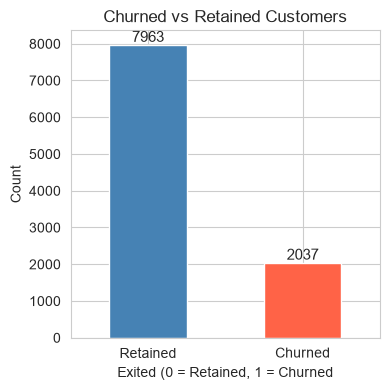

In [6]:
fig, ax = plt.subplots(figsize=(4,4))
df_clean['Exited'].value_counts().plot(
    kind='bar',
    color=['steelblue','tomato'],
    ax=ax,
    edgecolor='white'
)
ax.set_title("Churned vs Retained Customers")
ax.set_xlabel("Exited (0 = Retained, 1 = Churned")
ax.set_ylabel("Count")
ax.set_xticklabels(['Retained', 'Churned'], rotation=0)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',va='bottom',fontsize=11)
plt.tight_layout()
plt.show()      

In [7]:
#Summary
#Dataset: 10,000 rows, 14 columns — no nulls, no duplicates
#Binary fields validated: HasCrCard, IsActiveMember, Exited all strictly 0/1
#3 geographies confirmed: France, Spain, Germany
#Overall churn rate: ~20.37% — roughly 1 in 5 customers exited
#Notable: significant zero-balance customer population; Age ranges up to 92
#Non-analytical columns dropped: Year, Surname, CustomerId
#Working DataFrame: df_clean — 10,000 rows × 11 columns

#20.37% is actually a high churn rate for retail banking. Industry benchmarks typically sit around
#10–15% annually.This makes the segmentation work even more critical — the bank clearly has a retention
#problem, and your analysis will pinpoint exactly where it's concentrated.

In [8]:
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0,29,45,60,100],
    labels=['<30','30-45','46-60','60+'],
    include_lowest=True
)
print(df_clean['AgeGroup'].value_counts().reindex(['<30','30-45','46-60','60+']))
df_clean.groupby('AgeGroup')['Age'].agg(['min','max','count'])

AgeGroup
<30      1641
30-45    6248
46-60    1647
60+       464
Name: count, dtype: int64


,min,max,count
AgeGroup,,,
<30,18,29,1641
30-45,30,45,6248
46-60,46,60,1647
60+,61,92,464


In [9]:
df_clean['CreditBand'] = pd.cut(
    df_clean['CreditScore'],
    bins=[300,579,719,850],
    labels=['Low','Medium','High'],
    include_lowest=True
)
print(df_clean['CreditBand'].value_counts().reindex(['Low','Medium','High']))
df_clean.groupby('CreditBand')['CreditScore'].agg(['min', 'max', 'count'])

CreditBand
Low       2362
Medium    5202
High      2436
Name: count, dtype: int64


,min,max,count
CreditBand,,,
Low,350,579,2362
Medium,580,719,5202
High,720,850,2436


In [10]:
df_clean['TenureGroup'] = pd.cut(
    df_clean['Tenure'],
    bins=[-1,2,6,10],
    labels=['New','Mid-term','Long-term']  #New - 0 to 2 years; Mid-term-3 to 6 years; Long-term-7 to 10 years
)
print(df_clean['TenureGroup'].value_counts().reindex(['New','Mid-term','Long-term']))
df_clean.groupby('TenureGroup')['Tenure'].agg(['min', 'max', 'count'])

TenureGroup
New          2496
Mid-term     3977
Long-term    3527
Name: count, dtype: int64


,min,max,count
TenureGroup,,,
New,0,2,2496
Mid-term,3,6,3977
Long-term,7,10,3527


In [11]:
non_zero_median = df_clean.loc[df_clean['Balance']>0, 'Balance'].median()
print("Median of non-zero balances:", non_zero_median)

def balance_segment(balance):
    if balance == 0:
        return 'Zero'
    elif balance <= non_zero_median:
        return'Low'
    else:
        return 'High'

df_clean['BalanceSegment'] = df_clean['Balance'].apply(balance_segment)
print(df_clean['BalanceSegment'].value_counts().reindex(['Zero','Low','High']))
df_clean.groupby('BalanceSegment')['Balance'].agg(['min', 'max', 'count'])

Median of non-zero balances: 119839.69
BalanceSegment
Zero    3617
Low     3192
High    3191
Name: count, dtype: int64


,min,max,count
BalanceSegment,,,
High,119852.01,250898.09,3191
Low,3768.69,119839.69,3192
Zero,0.00,0.00,3617


In [12]:
high_value_threshold = df_clean['Balance'].quantile(0.75)
print("High-value threshold (75th pecentile):", high_value_threshold)
df_clean['HighValueFlag'] = df_clean['Balance'] > high_value_threshold
print(df_clean['HighValueFlag'].value_counts())
df_clean.groupby('HighValueFlag')['Balance'].agg(['min','max','count'])

High-value threshold (75th pecentile): 127644.24
HighValueFlag
False    7500
True     2500
Name: count, dtype: int64


,min,max,count
HighValueFlag,,,
False,0.00,127642.44,7500
True,127649.64,250898.09,2500


In [13]:
print("Shape:", df_clean.shape)
df_clean.head(10)

Shape: (10000, 16)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditBand,TenureGroup,BalanceSegment,HighValueFlag
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30-45,Medium,New,Zero,False
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30-45,Medium,New,Low,False
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,Low,Long-term,High,True
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-45,Medium,New,Zero,False
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-45,High,New,High,False
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,30-45,Medium,Long-term,Low,False
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0,46-60,High,Long-term,Zero,False
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,<30,Low,Mid-term,Low,False
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,30-45,Low,Mid-term,High,True
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,<30,Medium,New,High,True


In [14]:
#Result Summary
#Column              Groups                  Distribution
#AgeGroup        <30, 30-45, 46-60, 60+   Heavily concentrated in 30-45 (6,248)
#CreditBand    Low, Medium, High          Medium dominant (5,202), Low/High roughly even
#TenureGroup   New, Mid-term, Long-term   Fairly balanced — Long-term slightly highest (3,527)
#BalanceSegment   Zero, Low, High         Zero (3,617) ≈ Low (3,192) ≈ High (3,191) — nicely balanced 3-way split
#HighValueFlag      True/False            2,500 True / 7,500 False — clean 25/75 split, as expected from quantile(0.75)

           Churn Rate (%)  Churn Count  Total Customes  Churn Contribution (%)
Geography                                                                     
France              16.15          810            5014                   39.76
Germany             32.44          814            2509                   39.96
Spain               16.67          413            2477                   20.27


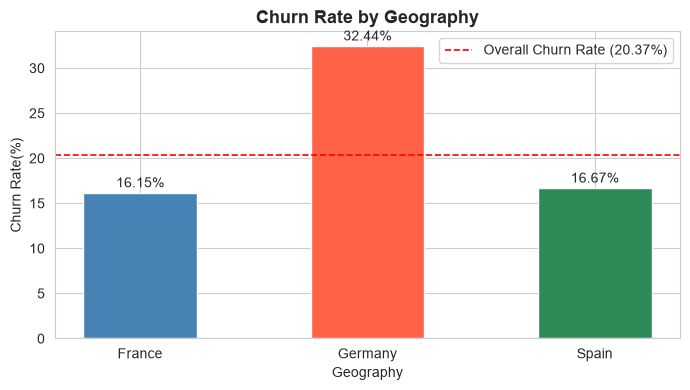

In [15]:
#Churn Distribution Analysis
#churn rate by geography
geography_churn = pd.DataFrame({
    'Churn Rate (%)':df_clean.groupby('Geography')['Exited'].mean() * 100,
    'Churn Count':df_clean.groupby('Geography')['Exited'].sum(),
    'Total Customes':df_clean.groupby('Geography')['Exited'].count()
}).round(2)
geography_churn['Churn Contribution (%)'] = (
    (geography_churn['Churn Count'] / df_clean['Exited'].sum()) *100
).round(2)
print(geography_churn)

fig, ax = plt.subplots(figsize=(7,4))

bars = ax.bar(
    geography_churn.index,
    geography_churn['Churn Rate (%)'],
    color=['steelblue','tomato','seagreen'],
    edgecolor='white',
    width=0.5
)

ax.axhline(y=20.37, color='red', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center',va='bottom',fontsize=10
    )
ax.set_title('Churn Rate by Geography',fontsize=13, fontweight='bold')
ax.set_xlabel('Geography')
ax.set_ylabel('Churn Rate(%)')
ax.legend()
plt.tight_layout()
plt.show()


          Churn Rate (%)  Churn Count  Total Customes  Churn Contribution (%)
AgeGroup                                                                     
<30                 7.56          124            1641                    6.09
30-45              15.30          956            6248                   46.93
46-60              51.12          842            1647                   41.34
60+                24.78          115             464                    5.65


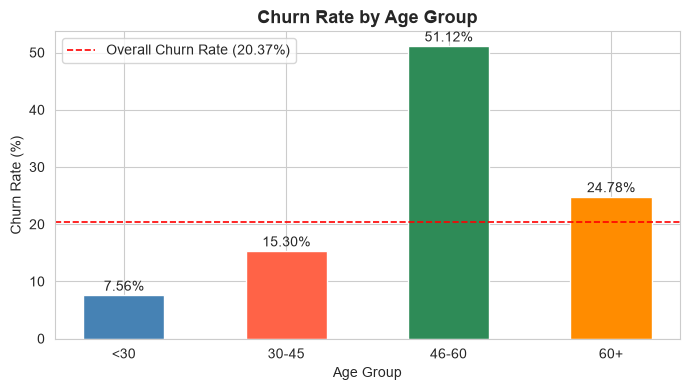

In [16]:
#churn rate by age group
age_churn = pd.DataFrame({
    'Churn Rate (%)':df_clean.groupby('AgeGroup', observed=True)['Exited'].mean() * 100,
    'Churn Count':df_clean.groupby('AgeGroup', observed=True)['Exited'].sum(),
    'Total Customes':df_clean.groupby('AgeGroup', observed=True)['Exited'].count()
}).round(2)

age_churn['Churn Contribution (%)'] = (
    (age_churn['Churn Count']/df_clean['Exited'].sum())*100
).round(2)

print(age_churn)

# Visualization
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    age_churn.index,
    age_churn['Churn Rate (%)'],
    color=['steelblue', 'tomato', 'seagreen','darkorange'],
    edgecolor='white',
    width=0.5
)

ax.axhline(y=20.37, color='red', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Churn Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

            Churn Rate (%)  Churn Count  Total Customes  \
CreditBand                                                
Low                  22.02          520            2362   
Medium               19.65         1022            5202   
High                 20.32          495            2436   

            Churn Contribution (%)  
CreditBand                          
Low                          25.53  
Medium                       50.17  
High                         24.30  


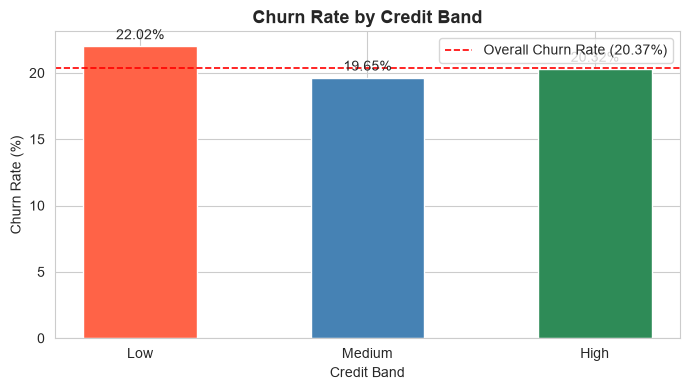

In [17]:
#churn rate by crdit band
credit_churn = pd.DataFrame({
    'Churn Rate (%)':df_clean.groupby('CreditBand', observed=True)['Exited'].mean() * 100,
    'Churn Count':df_clean.groupby('CreditBand', observed=True)['Exited'].sum(),
    'Total Customes':df_clean.groupby('CreditBand', observed=True)['Exited'].count()
}).round(2)

credit_churn['Churn Contribution (%)'] = (
    (credit_churn['Churn Count']/df_clean['Exited'].sum())*100
).round(2)

print(credit_churn)

# Visualization
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    credit_churn.index,
    credit_churn['Churn Rate (%)'],
    color=['tomato', 'steelblue', 'seagreen'],
    edgecolor='white',
    width=0.5
)

ax.axhline(y=20.37, color='red', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Churn Rate by Credit Band', fontsize=13, fontweight='bold')
ax.set_xlabel('Credit Band')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

             Churn Rate (%)  Churn Count  Total Customers  \
TenureGroup                                                 
New                   21.15          528             2496   
Mid-term              20.64          821             3977   
Long-term             19.51          688             3527   

             Churn Contribution (%)  
TenureGroup                          
New                           25.92  
Mid-term                      40.30  
Long-term                     33.78  


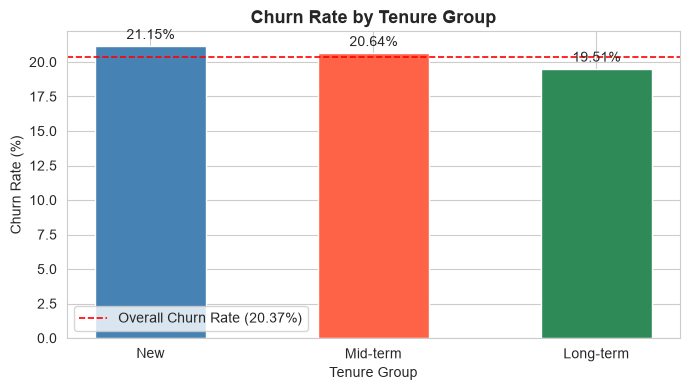

In [18]:
# Churn Rate by TenureGroup
tenure_churn = pd.DataFrame({
    'Churn Rate (%)': df_clean.groupby('TenureGroup', observed=True)['Exited'].mean() * 100,
    'Churn Count': df_clean.groupby('TenureGroup', observed=True)['Exited'].sum(),
    'Total Customers': df_clean.groupby('TenureGroup', observed=True)['Exited'].count()
}).round(2)

tenure_churn['Churn Contribution (%)'] = (
    (tenure_churn['Churn Count'] / df_clean['Exited'].sum()) * 100
).round(2)

print(tenure_churn)

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    tenure_churn.index,
    tenure_churn['Churn Rate (%)'],
    color=['steelblue', 'tomato', 'seagreen'],
    edgecolor='white',
    width=0.5
)

ax.axhline(y=20.37, color='red', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

                Churn Rate (%)  Churn Count  Total Customers  \
BalanceSegment                                                 
Zero                     13.82          500             3617   
Low                      24.00          766             3192   
High                     24.16          771             3191   

                Churn Contribution (%)  
BalanceSegment                          
Zero                             24.55  
Low                              37.60  
High                             37.85  


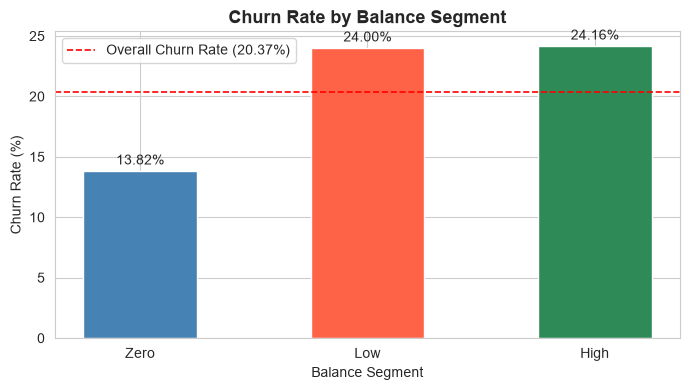

In [19]:
# Churn Rate by BalanceSegment
balance_churn = pd.DataFrame({
    'Churn Rate (%)': df_clean.groupby('BalanceSegment')['Exited'].mean() * 100,
    'Churn Count': df_clean.groupby('BalanceSegment')['Exited'].sum(),
    'Total Customers': df_clean.groupby('BalanceSegment')['Exited'].count()
}).round(2)

balance_churn['Churn Contribution (%)'] = (
    (balance_churn['Churn Count'] / df_clean['Exited'].sum()) * 100
).round(2)

balance_churn = balance_churn.reindex(['Zero', 'Low', 'High'])

print(balance_churn)
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    balance_churn.index,
    balance_churn['Churn Rate (%)'],
    color=['steelblue', 'tomato', 'seagreen'],
    edgecolor='white',
    width=0.5
)

ax.axhline(y=20.37, color='red', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Churn Rate by Balance Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Balance Segment')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

               Churn Rate (%)  Churn Count  Total Customers  \
NumOfProducts                                                 
1                       27.71         1409             5084   
2                        7.58          348             4590   
3                       82.71          220              266   
4                      100.00           60               60   

               Churn Contribution (%)  
NumOfProducts                          
1                               69.17  
2                               17.08  
3                               10.80  
4                                2.95  


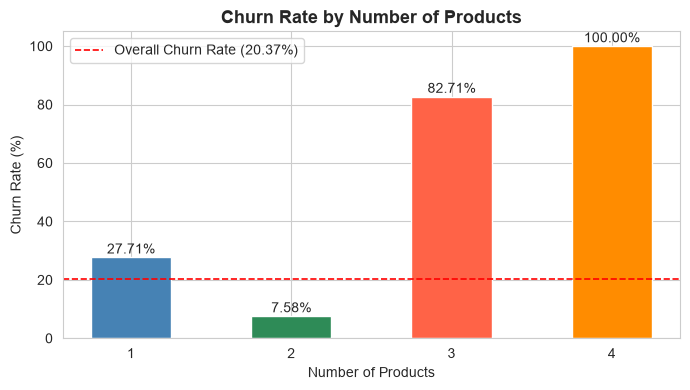

In [20]:
# Churn Rate by NumOfProducts
products_churn = pd.DataFrame({
    'Churn Rate (%)': df_clean.groupby('NumOfProducts')['Exited'].mean() * 100,
    'Churn Count': df_clean.groupby('NumOfProducts')['Exited'].sum(),
    'Total Customers': df_clean.groupby('NumOfProducts')['Exited'].count()
}).round(2)

products_churn['Churn Contribution (%)'] = (
    (products_churn['Churn Count'] / df_clean['Exited'].sum()) * 100
).round(2)

print(products_churn)
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    products_churn.index.astype(str),
    products_churn['Churn Rate (%)'],
    color=['steelblue', 'seagreen', 'tomato', 'darkorange'],
    edgecolor='white',
    width=0.5
)

ax.axhline(y=20.37, color='red', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Churn Rate by Number of Products', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
#Summary of Key Findings So Far
#Finding            Insight
#Germany            2x churn rate of France/Spain
#Age                46-6051% churn — highest risk segment
#2 products         Sweetspot — lowest churn at 7.58%
#3-4 products       Danger zone — 83-100% churn
#Zero balance       Surprisingly loyal — 13.82% chur
#nCredit/Tenure     Weak predictors — minimal variation

          CreditScore    Age   Balance  NumOfProducts  Tenure  EstimatedSalary
Retained       651.85  37.41  72745.30           1.54    5.03         99738.39
Churned        645.35  44.84  91108.54           1.48    4.93        101465.68

With Difference Row:
            CreditScore    Age   Balance  NumOfProducts  Tenure  \
Retained         651.85  37.41  72745.30           1.54    5.03   
Churned          645.35  44.84  91108.54           1.48    4.93   
Difference        -6.50   7.43  18363.24          -0.06   -0.10   

            EstimatedSalary  
Retained           99738.39  
Churned           101465.68  
Difference          1727.29  


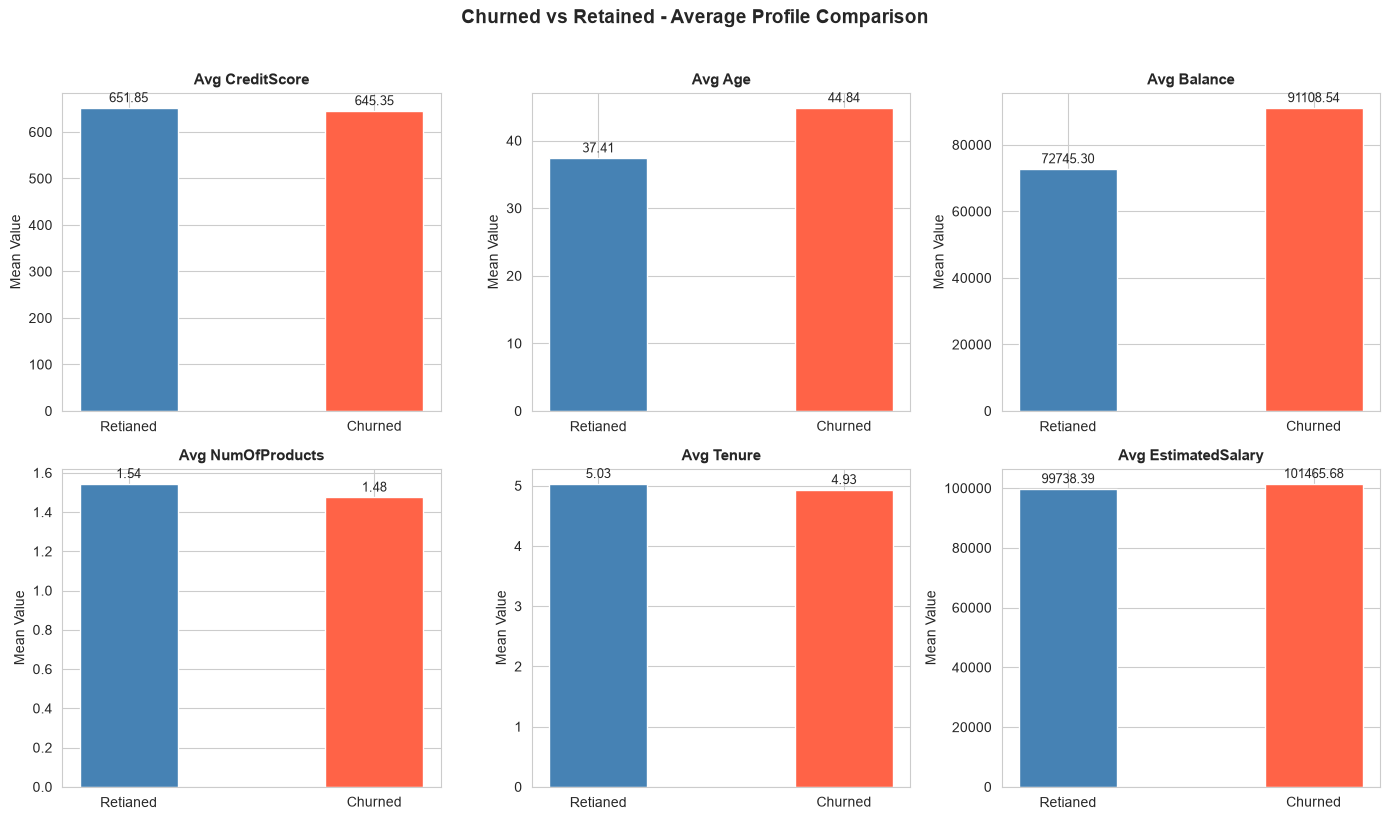

In [22]:
#churned vs retained profile comparison
numeric_cols = ['CreditScore','Age','Balance','NumOfProducts','Tenure','EstimatedSalary']

profile_comp = df_clean.groupby('Exited')[numeric_cols].mean().round(2)
profile_comp.index = ['Retained','Churned']
print(profile_comp)

#diff row to highlight the gap
profile_comp.loc['Difference'] = profile_comp.loc['Churned'] - profile_comp.loc['Retained']
print("\nWith Difference Row:")
print(profile_comp.round(2))

fig, axes = plt.subplots(2,3, figsize=(14,8))
axes=axes.flatten()

colors=['steelblue','tomato']
for i, col in enumerate(numeric_cols):
    vals=[
        df_clean[df_clean['Exited'] == 0][col].mean(),
        df_clean[df_clean['Exited'] == 1][col].mean()
    ]
    bars= axes[i].bar(['Retianed','Churned'], vals, color=colors, edgecolor='white', width=0.4)

    for bar in bars:
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + (max(vals) * 0.01),
            f'{bar.get_height():.2f}',
            ha='center',va='bottom',fontsize=9
        )

        axes[i].set_title(f'Avg {col}',fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Mean Value')

fig.suptitle('Churned vs Retained - Average Profile Comparison',
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
#Summary
#Churned customers are on average 7 years older and hold balances $18,363 higher than
#retained customers. The bank's churn problem is not concentrated among disengaged or 
#low-value customers — it is losing older, wealthier customers at disproportionate rates.

        Churn Rate (%)  Churn Count  Total Customers  Churn Contribution (%)
Gender                                                                      
Female           25.07         1139             4543                   55.92
Male             16.46          898             5457                   44.08


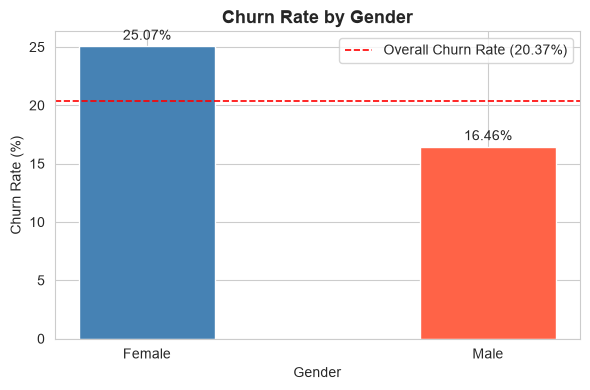

In [24]:
#churn rate by gender
gender_churn = pd.DataFrame({
    'Churn Rate (%)':df_clean.groupby('Gender')['Exited'].mean()*100,
    'Churn Count':df_clean.groupby('Gender')['Exited'].sum(),
    'Total Customers':df_clean.groupby('Gender')['Exited'].count()
}).round(2)

gender_churn['Churn Contribution (%)'] = (
    (gender_churn['Churn Count']/df_clean['Exited'].sum())*100
).round(2)
print(gender_churn)

fig, ax = plt.subplots(figsize=(6,4))
bars=ax.bar(
    gender_churn.index,
    gender_churn['Churn Rate (%)'],
    color=['steelblue','tomato'],
    edgecolor='white',
    width=0.4
)

ax.axhline(y=20.37, color='red', linestyle='--',linewidth=1.2, label='Overall Churn Rate (20.37%)')
for bar in bars:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.3,
        f'{bar.get_height():.2f}%',
        ha='center',va='bottom',fontsize=10
    )
ax.set_title('Churn Rate by Gender',fontsize=13, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

                Churn Rate (%)  Churn Count  Total Customers  \
IsActiveMember                                                 
0                        26.85         1302             4849   
1                        14.27          735             5151   

                Churn Contribution (%)  
IsActiveMember                          
0                                63.92  
1                                36.08  
                Churn Rate (%)  Churn Count  Total Customers  \
IsActiveMember                                                 
0                        26.85         1302             4849   
1                        14.27          735             5151   

                Churn Contribution (%)  
IsActiveMember                          
0                                63.92  
1                                36.08  


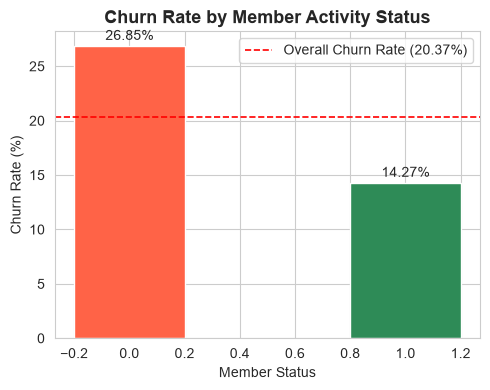

In [25]:
#churn rate by IsActiveMember
active_churn = pd.DataFrame({
    'Churn Rate (%)':df_clean.groupby('IsActiveMember')['Exited'].mean()*100,
    'Churn Count':df_clean.groupby('IsActiveMember')['Exited'].sum(),
    'Total Customers':df_clean.groupby('IsActiveMember')['Exited'].count()
}).round(2)

active_churn['Churn Contribution (%)'] = (
    (active_churn['Churn Count']/df_clean['Exited'].sum())*100
).round(2)
print(active_churn)
print(active_churn)

fig, ax = plt.subplots(figsize=(5,4))
bars=ax.bar(
    active_churn.index,
    active_churn['Churn Rate (%)'],
    color=['tomato','seagreen'],
    edgecolor='white',
    width=0.4
)

ax.axhline(y=20.37, color='red', linestyle='--',linewidth=1.2, label='Overall Churn Rate (20.37%)')
for bar in bars:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.3,
        f'{bar.get_height():.2f}%',
        ha='center',va='bottom',fontsize=10
    )
ax.set_title('Churn Rate by Member Activity Status',fontsize=13, fontweight='bold')
ax.set_xlabel('Member Status')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

        Inactive  Active
Gender                  
Female     32.09   18.13
Male       22.28   11.20


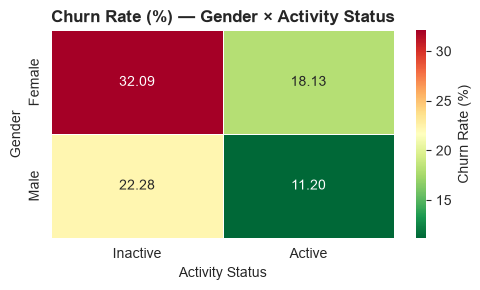

In [26]:
# Cross-tab of Gender and Activity vs Churn
cross_tab = df_clean.groupby(['Gender', 'IsActiveMember'])['Exited'].mean().mul(100).round(2).unstack()
cross_tab.columns = ['Inactive', 'Active']
print(cross_tab)
# Heatmap
fig, ax = plt.subplots(figsize=(5, 3))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Churn Rate (%)'}
)

ax.set_title('Churn Rate (%) — Gender × Activity Status', fontsize=12, fontweight='bold')
ax.set_xlabel('Activity Status')
ax.set_ylabel('Gender')
plt.tight_layout()
plt.show()

In [27]:
#Summary
#Member activity status emerges as the strongest single predictor of churn, with inactive
#members churning at 26.85% compared to 14.27% for active members. Gender compounds this 
#effect — inactive female customers represent the highest-risk profile at 32.09% churn,
#while active male customers are the most loyal at 11.20%. These findings suggest
#targeted re-engagement of inactive female customers as the highest-priority retention 
#intervention.

Gender     Female   Male
Geography               
France      20.34  12.71
Germany     37.55  27.81
Spain       21.21  13.11


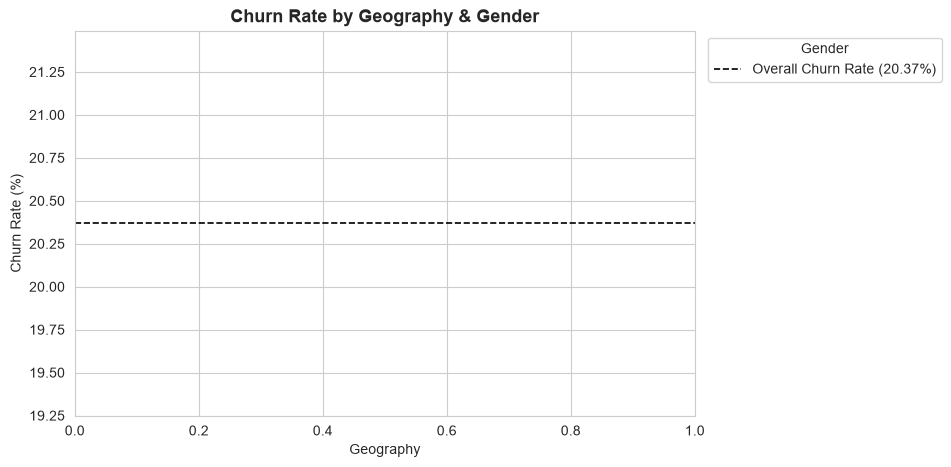

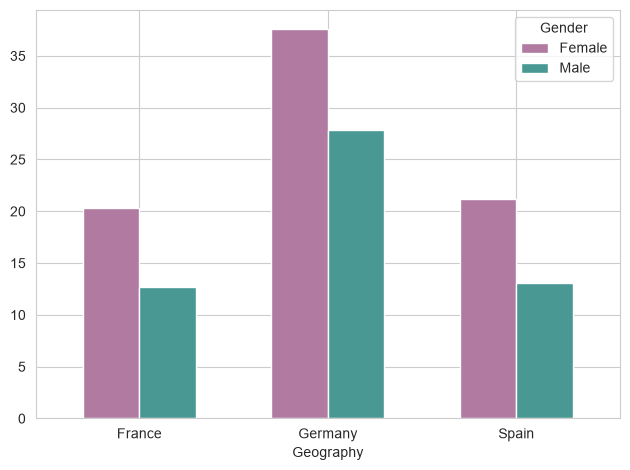

In [28]:
#Geography x Gender churn rate
geo_gender = df_clean.groupby(['Geography','Gender'])['Exited'].mean().mul(100).round(2).unstack()
print(geo_gender)

fig,ax = plt.subplots(figsize = (8,5))
geo_gender.plot(
    kind='bar',
    color=['#B07AA1','#499894'],
    edgecolor='white',
    width=0.6
)

ax.axhline(y=20.37, color='black', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')
ax.set_title('Churn Rate by Geography & Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Geography')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
ax.legend(title='Gender', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

AgeGroup     <30  30-45  46-60    60+
Geography                            
France      5.20  11.87  45.79  19.91
Germany    12.63  25.30  67.33  38.94
Spain       7.94  12.52  40.66  20.83


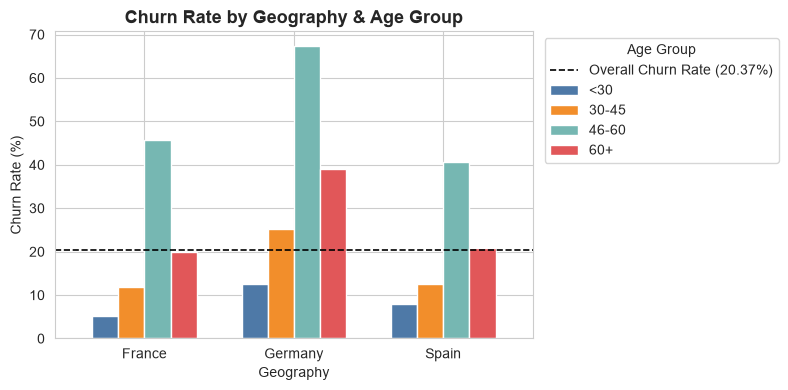

In [29]:
#Geography x Age
geo_age = df_clean.groupby(
    ['Geography','AgeGroup'], observed=True)['Exited'].mean().mul(100).round(2).unstack()
print(geo_age)

fig, ax = plt.subplots(figsize=(8,4))
geo_age.plot(
    kind='bar',
    ax=ax,
    color = ['#4E79A7','#F28E2B','#76B7B2','#E15759'],
    edgecolor = 'white',
    width = 0.7
)

ax.axhline(y=20.37, color='black', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')
ax.set_title('Churn Rate by Geography & Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Geography')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
ax.legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

                      Balance  EstimatedSalary
Geography Exited                              
France    Retained   60339.28         99217.10
          Churned    71192.80        103439.28
Germany   Retained  119427.11        102414.66
          Churned   120361.08         98403.89
Spain     Retained   59678.07         98602.37
          Churned    72513.35        103629.55


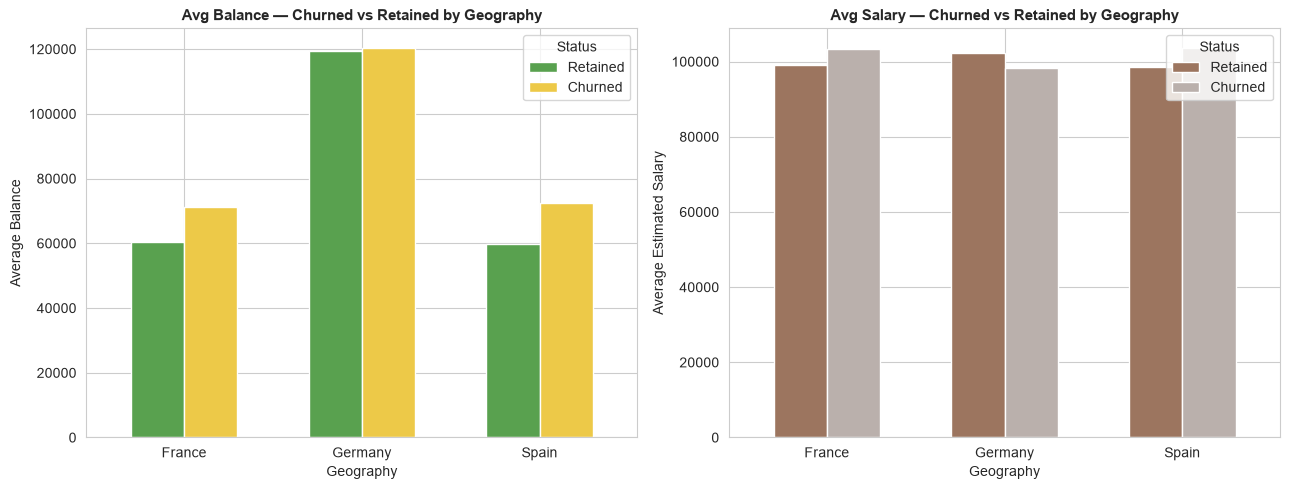

In [30]:
#average balance and salary by churn status across geographies
financial_profile = df_clean.groupby(['Geography','Exited'])[['Balance','EstimatedSalary']].mean().round(2)
financial_profile.index = financial_profile.index.set_levels(['Retained','Churned'], level=1)
print(financial_profile)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 — Balance
balance_pivot = df_clean.groupby(['Geography', 'Exited'])['Balance'].mean().unstack()
balance_pivot.columns = ['Retained', 'Churned']

balance_pivot.plot(
    kind='bar',
    ax=axes[0],
    color=['#59A14F', '#EDC948'],
    edgecolor='white',
    width=0.6
)
axes[0].set_title('Avg Balance — Churned vs Retained by Geography', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Geography')
axes[0].set_ylabel('Average Balance')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Status')

# Plot 2 — Salary
salary_pivot = df_clean.groupby(['Geography', 'Exited'])['EstimatedSalary'].mean().unstack()
salary_pivot.columns = ['Retained', 'Churned']

salary_pivot.plot(
    kind='bar',
    ax=axes[1],
    color=['#9C755F', '#BAB0AC'],
    edgecolor='white',
    width=0.6
)
axes[1].set_title('Avg Salary — Churned vs Retained by Geography', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Geography')
axes[1].set_ylabel('Average Estimated Salary')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()

In [31]:
#Summary of Cross-segment Analysis
#Cross-segment analysis reveals Germany's 46-60 age group as the highest-risk 
#intersection in the dataset at 67.33% churn — more than three times the overall rate.
#While balance differentials drive churn in France and Spain (churned customers hold
#18-21% higher balances), Germany's churned and retained customers show near-identical
#balances (~120K), suggesting non-financial drivers such as service dissatisfaction or 
#product misalignment are responsible for German attrition.

            Churn Rate (%)  Churn Count  Total Customers  \
Regular              19.27         1445             7500   
High Value           23.68          592             2500   

            Churn Contribution (%)  
Regular                      70.94  
High Value                   29.06  


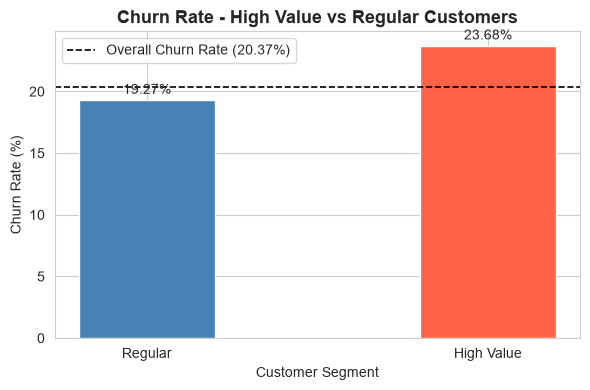

In [32]:
#High value customer churn analysis
#churn rate among high value vs regular customers
hv_churn = pd.DataFrame({
    'Churn Rate (%)':df_clean.groupby('HighValueFlag')['Exited'].mean()*100,
    'Churn Count': df_clean.groupby('HighValueFlag')['Exited'].sum(),
    'Total Customers':df_clean.groupby('HighValueFlag')['Exited'].count()
}).round(2)
hv_churn['Churn Contribution (%)'] = (
    (hv_churn['Churn Count']/df_clean['Exited'].sum())*100
).round(2)

hv_churn.index = ['Regular','High Value']
print(hv_churn)

fig, ax = plt.subplots(figsize = (6,4))
bars = ax.bar(
    hv_churn.index,
    hv_churn['Churn Rate (%)'],
    color = ['steelblue','tomato'],
    edgecolor='white',
    width=0.4
)

ax.axhline(y=20.37, color='black', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center',va='bottom', fontsize=10
    )

ax.set_title('Churn Rate - High Value vs Regular Customers', fontsize=13, fontweight='bold')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
#total balance held by churned high value customers
churned_hv = df_clean[(df_clean['HighValueFlag'] == True) &
             (df_clean['Exited'] == 1)]
retained_hv = df_clean[(df_clean['HighValueFlag'] == True) &
             (df_clean['Exited'] == 0)]

total_hv_balance = df_clean[df_clean['HighValueFlag'] == True]['Balance'].sum()
churned_hv_balance = churned_hv['Balance'].sum()
revenue_risk_pct = (churned_hv_balance / total_hv_balance) * 100

print(f"Total High Value Customers: {len(df_clean[df_clean['HighValueFlag'] == True])}")
print(f"Churned High Value Customers: {len(churned_hv)}")
print(f"Retained High Value Customers: {len(retained_hv)}")
print(f"\nTotal Balance (High Value Segment): ${total_hv_balance:,.2f}")
print(f"Balance at Risk (Churned HV): ${churned_hv_balance:,.2f}")
print(f"Revenue Risk %: {revenue_risk_pct}%")

Total High Value Customers: 2500
Churned High Value Customers: 592
Retained High Value Customers: 1908

Total Balance (High Value Segment): $372,627,057.46
Balance at Risk (Churned HV): $88,654,932.44
Revenue Risk %: 23.79186660365283%



High Value Customers - Financial Profile:
            Balance  EstimatedSalary
Retained  148832.35        100522.75
Churned   149754.95        101078.40


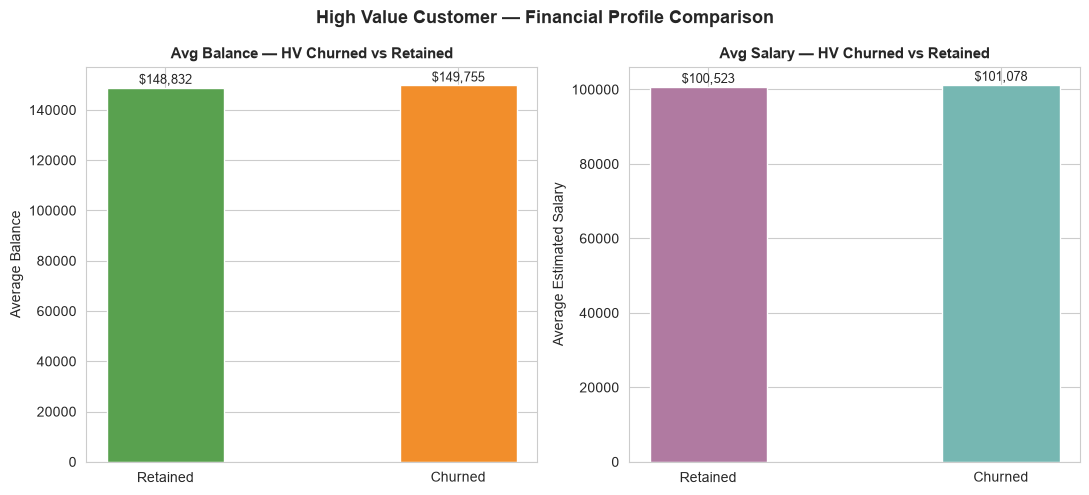

In [34]:
#Among high value customers - compare salary and balance of churned vs retained
hv_financial = df_clean[df_clean['HighValueFlag'] == True].groupby('Exited')[[
                'Balance','EstimatedSalary']].mean().round(2)
hv_financial.index = ['Retained','Churned']
print("\nHigh Value Customers - Financial Profile:")
print(hv_financial)

# Visualization — side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Balance comparison
axes[0].bar(
    hv_financial.index,
    hv_financial['Balance'],
    color=['#59A14F', '#F28E2B'],
    edgecolor='white',
    width=0.4
)
axes[0].set_title('Avg Balance — HV Churned vs Retained', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Balance')

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'${bar.get_height():,.0f}',
        ha='center', va='bottom', fontsize=9
    )

# Salary comparison
axes[1].bar(
    hv_financial.index,
    hv_financial['EstimatedSalary'],
    color=['#B07AA1', '#76B7B2'],
    edgecolor='white',
    width=0.4
)
axes[1].set_title('Avg Salary — HV Churned vs Retained', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Average Estimated Salary')

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'${bar.get_height():,.0f}',
        ha='center', va='bottom', fontsize=9
    )

plt.suptitle('High Value Customer — Financial Profile Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


High Value Churn by Geography:
           Total  Churned  Churn_Rate  Churn Contribution (%)
Geography                                                    
France      1056      214       20.27                   36.15
Germany      944      274       29.03                   46.28
Spain        500      104       20.80                   17.57


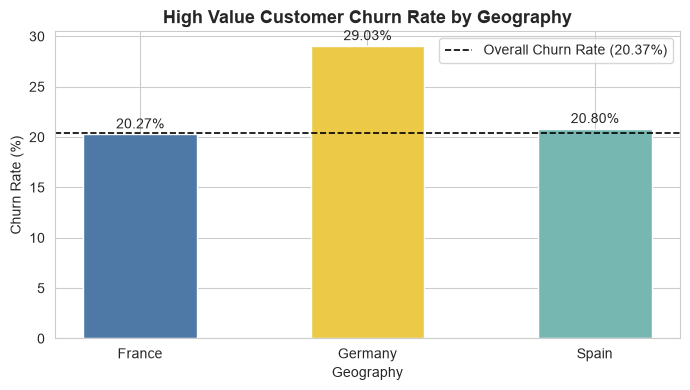

In [35]:
# Where are high value churners concentrated geographically?
hv_geo = df_clean[df_clean['HighValueFlag'] == True].groupby('Geography').agg(
    Total=('Exited', 'count'),
    Churned=('Exited', 'sum'),
    Churn_Rate=('Exited', lambda x: (x.sum() / x.count() * 100).round(2))
).round(2)

hv_geo['Churn Contribution (%)'] = (
    (hv_geo['Churned'] / hv_geo['Churned'].sum()) * 100
).round(2)

print("\nHigh Value Churn by Geography:")
print(hv_geo)

# Visualization
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    hv_geo.index,
    hv_geo['Churn_Rate'],
    color=['#4E79A7', '#EDC948', '#76B7B2'],
    edgecolor='white',
    width=0.5
)

ax.axhline(y=20.37, color='black', linestyle='--', linewidth=1.2, label='Overall Churn Rate (20.37%)')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('High Value Customer Churn Rate by Geography', fontsize=13, fontweight='bold')
ax.set_xlabel('Geography')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
#Summary
#High value customers — defined as those in the top quartile of account balance (above 
#$127,644) — churn at 23.68%, exceeding the rate of regular customers at 19.27%. The financial
#profile of churned and retained high value customers is virtually identical (balance 
#difference of $922, salary difference of $555), indicating that churn among premium customers
#is driven by non-financial factors rather than wealth mobility. The total balance at risk
#from high value churn stands at $88,654,932 — representing 23.79% of the entire high value
#segment's deposits. Germany accounts for 46.28% of high value churn despite holding only
#37.76% of high value customers, compounding the geographic risk identified earlier.